<a href="https://colab.research.google.com/github/MiguelPastorB/pastorbeltra/blob/main/Entornos_Complejos/Approximate.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Práctica 1 Parte 3: Entornos complejos - Métodos aproximados
- **Alumno:** Pastor Beltrá, Miguel
- **Asignatura:** Extensiones de Machine Learning
- **Curso:** 2025/2026
- **Grupo:** pastorbeltra

**Índice**   
1. [Introducción](#introduccion)
2. [Desarrollo](#desarrollo)
3. [Algoritmos](#algoritmos)
4. [Evaluación](#evaluacion)
5. [Conclusiones](#conclusiones)
6. [Uso de la IA generativa](#ia-generativa)
7. [Bibliografía y referencias](#referencias)

# 1. Introducción <a name="introduccion"></a>

En esta sección, abordamos el aprendizaje en entornos con espacios de estados continuos, donde la representación tabular resulta inmanejable. Para ello, implementamos técnicas de aproximación de funciones mediante redes neuronales profundas, permitiendo al agente generalizar el conocimiento entre estados similares.

# 2. Desarrollo <a name="desarrollo"></a>

En este apartado, describimos el diseño de nuestra arquitectura de redes neuronales profundas y la configuración del entorno **CartPole-v1**, justificando la elección de hiperparámetros como la tasa de aprendizaje ($\alpha$) y el factor de descuento ($\gamma$) para garantizar la estabilidad del entrenamiento. Asimismo, detallamos el proceso metodológico seguido para implementar tanto SARSA semi-gradiente como Deep Q-Learning (DQN), asegurando la reproducibilidad de nuestros experimentos mediante el control estricto de las semillas aleatorias en PyTorch y el entorno de simulación.

## 2.1. Entorno Colab y VSCode

A continuación, incluimos algunas celdas auxiliares para adaptar el entorno de ejecución en Colab, permitiendo acceder correctamente al repositorio y a los módulos del proyecto.

In [ ]:
!rm -r pastorbeltra/
!git clone https://github.com/MiguelPastorB/pastorbeltra.git
%cd pastorbeltra/

In [ ]:
!pip install -r requirements.txt

Esta celda de código añade la carpeta src al path de Python, lo que permite importar correctamente los módulos del proyecto sin necesidad de instalar el paquete.

In [ ]:
%cd Entornos_Complejos/

In [7]:
import sys
import os

# Añadimos la carpeta 'src' al path de búsqueda de Python
sys.path.append(os.path.abspath('src'))

En esta celda configuramos el ecosistema de trabajo para la fase de aproximación de funciones, integrando las capacidades de cálculo tensorial de PyTorch con los agentes de aprendizaje profundo DQN y SARSA semi-gradiente definidos en nuestro proyecto. Hemos establecido una semilla de reproducibilidad  que afecta tanto a las librerías de muestreo aleatorio como a la inicialización de los pesos de las redes neuronales, garantizando así que los resultados y la comparativa de rendimiento sean consistentes en cada ejecución.

In [8]:
# Importamos las librerías necesarias
import numpy as np
import random
import torch

# Importamos nuestros algoritmos y funciones de visualización
import gymnasium as gym
from src.approximate_methods.dqn import DQNAgent
from src.approximate_methods.sarsa_semi_gradient import SARSASemiGradientAgent
from src.utils.trainer import train_approximate_agent, train_sarsa_approximate
from src.utils.plotting import plot_learning_curves, plot_steps_per_episode

# Establecemos una semilla para reproducibilidad
seed = 2024
np.random.seed(seed)
random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed(seed)

# 3. Algoritmos <a name="algoritmos"></a>

Para esta celda de configuración del entorno y los hiperparámetros, es fundamental detallar cómo los elementos seleccionados afectan directamente a la estabilidad del aprendizaje profundo.

* **Definición del espacio de estados y acciones:** al instanciar **CartPole-v1**, pasamos de un entorno discreto (como el mapa de celdas de **FrozenLake**) a uno de **espacios continuos**. El agente recibe un vector de cuatro dimensiones: la posición del carro, su velocidad, el ángulo del poste y su velocidad angular. Esta transición es el motivo principal por el cual abandonamos las tablas Q, con valores decimales infinitos, una tabla no podría representar todas las combinaciones posibles. La red neuronal, en cambio, aprende a generalizar.

* **Garantía de condiciones iniciales:** en *CartPole*, el poste comienza con una pequeña inclinación aleatoria. Al fijar la semilla en este punto exacto (``env_continuous.reset(seed=seed)``), nos aseguramos de que tanto el agente **DQN** como el de **SARSA semi-gradiente** se enfrenten exactamente al mismo reto inicial.

* **Hiperparámetros en Deep RL:** los valores elegidos no son arbitrarios, se han escogido según las necesidades de estabilidad de las redes neuronales:

    * **LR ($0.001$):** una tasa de aprendizaje pequeña es importante en métodos aproximados. Si fuera muy alta, los pesos de la red oscilarían demasiado ante cada error de predicción, impidiendo que el agente consolide lo aprendido.
    * **GAMMA ($0.99$):** al ser un entorno de equilibrio, el agente debe ser previsor. Un factor de descuento alto asegura que el agente valore tanto el éxito inmediato (no caer ahora) como el futuro (mantener una posición que facilite el equilibrio en los próximos 100 pasos).
    * **N_EPISODES ($300$):** este número es suficiente para observar la convergencia en redes densas de tamaño moderado, permitiendo que el *Replay Buffer* en DQN se llene y empiece a proporcionar muestras de calidad para el entrenamiento.

In [ ]:
env_continuous = gym.make("CartPole-v1")

# Obtenemos las dimensiones del estado y el número de acciones
state_dim = env_continuous.observation_space.shape[0]
action_dim = env_continuous.action_space.n

# Reiniciamos el entorno con la semilla antes de empezar
env_continuous.reset(seed=seed)

# Hiperparámetros para Deep RL
LR = 0.001
GAMMA_APPROX = 0.99
N_EPISODES_APPROX = 300

# 4. Evaluación <a name="evaluacion"></a>

Evaluamos los siguientes agentes:

* **Agente 1: Deep Q-Learning (DQN):** este agente representa el enfoque off-policy mediante redes neuronales. Al ser instanciado, el DQNAgent no solo crea una red para tomar decisiones, sino que activa un mecanismo de Replay Buffer (memoria de experiencia). Durante el entrenamiento, el agente guarda miles de transiciones pasadas. En lugar de aprender solo de lo que le pasa ahora, extrae muestras aleatorias de su memoria para actualizar sus pesos. Esto es importante para que el agente no olvide cómo salvar el poste en ángulos extremos solo porque lleva un rato en una posición estable. En cuanto a la estabilidad, utiliza una Red Target (una copia de la red principal que se actualiza más lentamente) para que los valores de referencia no cambien constantemente, evitando que el aprendizaje se vuelva caótico.

* **Agente 2: SARSA Semi-Gradiente:** este agente implementa el enfoque on-policy adaptado a la aproximación de funciones. A diferencia de DQN, este agente no tiene memoria de experiencias pasadas; aprende al momento de la trayectoria que está recorriendo. Para actualizar sus pesos, el agente necesita conocer la acción actual ($A$) y la acción siguiente ($A'$) que marca su política. Esto hace que el aprendizaje sea mucho más sensible a las decisiones del momento. Si el agente decide explorar una acción arriesgada y falla, la red se actualiza inmediatamente con esa penalización. Se denomina Semi-gradiente porque al calcular la diferencia entre lo que esperaba y lo que obtuvo (el error TD), el agente asume que la estimación del estado siguiente es una verdad fija a corto plazo. No calcula el gradiente completo de toda la ecuación para ahorrar coste computacional y facilitar la convergencia de la red neuronal en tiempo real.

In [10]:
# Inicialización de resultados
results_approx = {}

# 1. Entrenar Deep Q-Learning (DQN)
dqn_agent = DQNAgent(state_dim, action_dim, lr=LR, gamma=GAMMA_APPROX)
results_approx['DQN'] = train_approximate_agent(env_continuous, dqn_agent, N_EPISODES_APPROX)

# 2. Entrenar SARSA Semi-Gradiente
sarsa_approx_agent = SARSASemiGradientAgent(state_dim, action_dim, lr=LR, gamma=GAMMA_APPROX)
results_approx['SARSA Semi-Gradiente'] = train_sarsa_approximate(env_continuous, sarsa_approx_agent, N_EPISODES_APPROX)

Nuestros resultados en el entorno **CartPole-v1** reflejan una clara superioridad del algoritmo DQN frente a SARSA Semi-Gradiente, logrando el primero alcanzar el máximo de supervivencia (cerca de 500 pasos) de forma consistente hacia el final del entrenamiento. Observamos que la curva de DQN presenta oscilaciones significativas, lo cual es indicativo de la inestabilidad inherente al aprendizaje con redes neuronales cuando el agente explora nuevas zonas del espacio continuo, aunque logra recuperarse rápidamente gracias al uso del Replay Buffer. Por el contrario, SARSA Semi-Gradiente muestra un aprendizaje mucho más lento y limitado, sin lograr despegar de niveles bajos de recompensa, esto se debe a su naturaleza on-policy, que en este escenario de control continuo presenta dificultades para generalizar de forma eficiente sin una memoria de experiencias pasadas que rompa la correlación temporal de los datos.

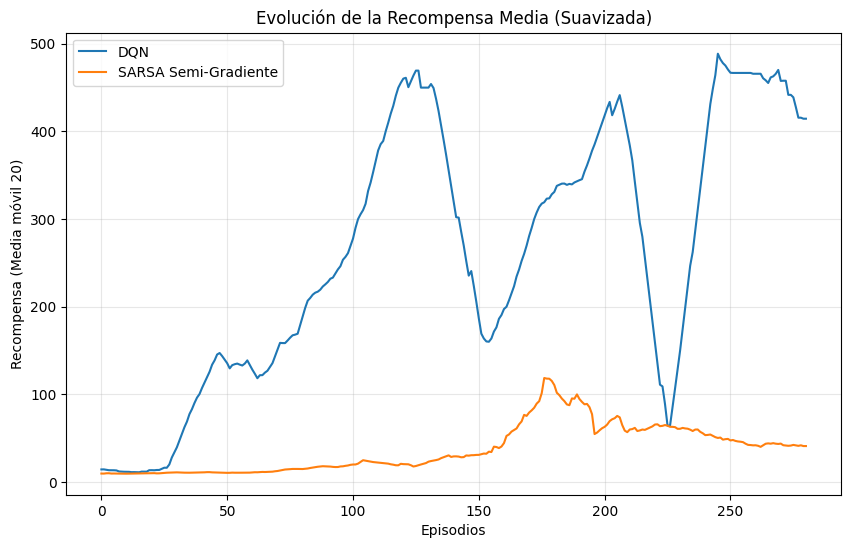

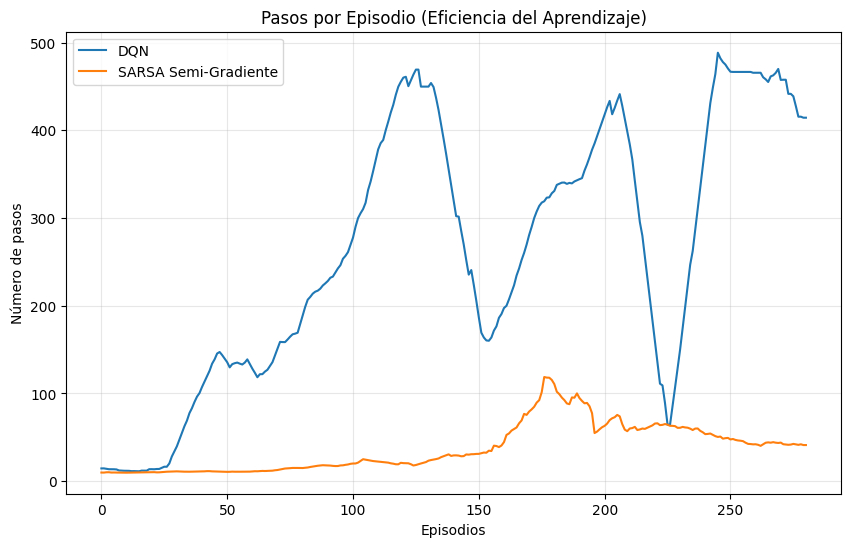

In [11]:
# Visualización de la comparativa en entornos continuos

plot_learning_curves(results_approx, window=20)
plot_steps_per_episode(results_approx, window=20)

# 5. Conclusiones <a name="conclusiones"></a>

Tras el análisis de los resultados obtenidos en el entorno **CartPole-v1**, concluimos que la superioridad de DQN sobre SARSA Semi-Gradiente radica en su capacidad de gestión de datos y estabilidad en la arquitectura. El uso del Replay Buffer ha resultado determinante para romper la correlación temporal de las muestras en el espacio continuo, permitiendo al agente generalizar a partir de experiencias diversas y repasar situaciones críticas de equilibrio. Aunque la curva de aprendizaje de DQN presenta oscilaciones propias de la sensibilidad de las redes neuronales ante ajustes de pesos, el uso de la red Target logra mitigar esta inestabilidad, permitiendo alcanzar el éxito máximo de supervivencia que SARSA, limitado por su naturaleza on-policy sin memoria, no consigue igualar.

La implementación ha validado que la transición hacia métodos de aproximación de funciones es la única vía viable para resolver problemas de alta dimensionalidad donde los métodos tabulares fallan. El éxito de la generalización sobre las cuatro variables de estado del entorno confirma que el agente ha aprendido patrones de control en lugar de memorizar posiciones exactas.

# 6. Uso de la IA generativa <a name="ia-generativa"></a>

### Prompt 1. ¿Por qué mi agente DQN tiene "caídas" repentinas en su rendimiento después de haber alcanzado la recompensa máxima?

Este fenómeno se conoce como "olvido catastrófico" o inestabilidad por sobreajuste. En entornos como CartPole, cuando el agente se vuelve muy bueno, el Replay Buffer se llena casi exclusivamente de experiencias de "éxito" (poste equilibrado). La red neuronal deja de ver ejemplos de fallos y "olvida" cómo reaccionar ante ángulos extremos. Para evitarlo, se recomienda usar un Replay Buffer más grande, ajustar el decaimiento de epsilon para mantener una exploración residual o emplear técnicas como Prioritized Experience Replay.

# 7. Bibliografía y referencias <a name="referencias"></a>

* Mnih, V., et al. (2015). Human-level control through deep reinforcement learning. Nature, 518(7540), 529-533. (Paper original de DeepMind sobre DQN que introduce el Replay Buffer y la Target Network).

* François-Lavet, V., et al. (2018). An Introduction to Deep Reinforcement Learning. Foundations and Trends in Machine Learning. (Recurso para profundizar en los problemas de inestabilidad y convergencia en métodos aproximados).